In [1]:
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any
import pandas as pd


@dataclass
class MassMatchResult:
    indices: np.ndarray                 # indices into sample1
    resampled_masses: np.ndarray        # masses from sample1 after resampling
    probs: np.ndarray                   # selection probability per element of sample1
    bin_edges: np.ndarray               # histogram bin edges used
    p1_density: np.ndarray              # estimated density of sample1 per bin
    p2_density: np.ndarray              # estimated density of sample2 per bin


def _freedman_diaconis_bins(x: np.ndarray) -> int:
    """Compute number of bins via Freedman–Diaconis rule."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 1
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        iqr = np.std(x) or 1.0
    h = 2 * iqr * (x.size ** (-1/3))
    if h <= 0:
        return int(np.sqrt(x.size)) or 1
    bins = int(np.ceil((x.max() - x.min()) / h))
    return max(bins, 1)


def _hist_density(x: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    """Histogram density estimate (counts divided by total and bin width)."""
    counts, _ = np.histogram(x, bins=bin_edges)
    widths = np.diff(bin_edges)
    total = x.size
    # Avoid division by zero
    density = counts / (total * widths)
    return density


def _bin_index(values: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    """Return index of the bin each value falls into (0..nbins-1). Values below/above
    edges are clipped to nearest bin."""
    # np.digitize returns 1..nbins for right=False
    idx = np.digitize(values, bin_edges[:-1], right=False) - 1
    # Clip to valid range
    return np.clip(idx, 0, len(bin_edges) - 2)


def mass_match_resample(
    mass1: np.ndarray,
    mass2: np.ndarray,
    size: Optional[int] = None,
    bins: Optional[int | str] = "fd",
    replace: bool = True,
    random_state: Optional[int] = None,
) -> MassMatchResult:
    """
    Resample sample 1 so that its mass distribution matches sample 2.

    Parameters
    ----------
    mass1 : array-like
        Masses of sample 1 (will be resampled from these).
    mass2 : array-like
        Masses of sample 2 (target distribution).
    size : int, optional
        Number of objects to draw. Defaults to len(mass2).
    bins : int or "fd", optional
        Number of histogram bins, or "fd" for Freedman–Diaconis rule.
    replace : bool, optional
        Sample with replacement (default True). If False, draws without replacement
        using probabilities proportional to weights (requires size <= len(mass1)).
    random_state : int, optional
        Seed for reproducibility.

    Returns
    -------
    MassMatchResult
        Contains resampled indices into sample 1, the resampled masses, selection
        probabilities, and diagnostic info.

    Notes
    -----
    This uses histogram-based importance resampling. For each mass in sample 1,
    we compute a weight proportional to p2(m) / p1(m), where p1 and p2 are density
    estimates from histograms with common binning. We then sample indices from
    sample 1 with probability proportional to these weights.
    """
    rng = np.random.default_rng(random_state)

    

    m1 = np.asarray(mass1).astype(float)
    m2 = np.asarray(mass2).astype(float)

    # Filter finite values
    m1 = m1[np.isfinite(m1)]
    m2 = m2[np.isfinite(m2)]

    if m1.size == 0 or m2.size == 0:
        raise ValueError("mass1 and mass2 must contain at least one finite value each")

    if size is None:
        size = m2.size

    # Determine bins
    if isinstance(bins, str):
        if bins.lower() == "fd":
            nbins = _freedman_diaconis_bins(np.concatenate([m1, m2]))
        else:
            raise ValueError("Unsupported bins specifier. Use int or 'fd'.")
    else:
        nbins = int(bins)
        if nbins < 1:
            raise ValueError("bins must be >= 1")

    # Expand range a touch to include extremes from both samples
    lo = np.min([m1.min(), m2.min()])
    hi = np.max([m1.max(), m2.max()])
    pad = 1e-6 * max(1.0, abs(hi - lo))
    bin_edges = np.linspace(lo - pad, hi + pad, nbins + 1)

    # Density estimates
    p1 = _hist_density(m1, bin_edges)
    p2 = _hist_density(m2, bin_edges)

    # Map each m1 to its bin and compute weights ~ p2/p1
    idx_bins = _bin_index(m1, bin_edges)
    eps = 1e-12
    weights = (p2[idx_bins] + eps) / (p1[idx_bins] + eps)

    # If all weights are zero (pathological), fall back to uniform
    if not np.any(np.isfinite(weights)) or np.all(weights <= 0):
        probs = np.repeat(1.0 / m1.size, m1.size)
    else:
        # Normalize to probabilities
        weights = np.where(np.isfinite(weights) & (weights > 0), weights, 0.0)
        total = weights.sum()
        if total == 0:
            probs = np.repeat(1.0 / m1.size, m1.size)
        else:
            probs = weights / total

    # Draw indices
    if replace:
        indices = rng.choice(m1.size, size=size, replace=True, p=probs)
    else:
        if size > m1.size:
            raise ValueError("Cannot sample without replacement with size > len(mass1)")
        # Use probabilities for weighted sampling without replacement
        # Gumbel-top-k trick for efficiency
        u = rng.random(m1.size)
        # Avoid log(0)
        safe_probs = np.maximum(probs, 1e-300)
        keys = np.log(safe_probs) - np.log(-np.log(u))
        indices = np.argpartition(-keys, size - 1)[:size]

    resampled_masses = m1[indices]

    return MassMatchResult(
        indices=indices.astype(int),
        resampled_masses=resampled_masses,
        probs=probs,
        bin_edges=bin_edges,
        p1_density=p1,
        p2_density=p2,
    )


def ks_distance(x: np.ndarray, y: np.ndarray) -> float:
    """Kolmogorov–Smirnov distance between two 1D samples."""
    x = np.sort(np.asarray(x))
    y = np.sort(np.asarray(y))
    nx, ny = x.size, y.size
    i = j = 0
    cdf_x = cdf_y = 0.0
    d = 0.0
    while i < nx and j < ny:
        if x[i] <= y[j]:
            i += 1
            cdf_x = i / nx
        else:
            j += 1
            cdf_y = j / ny
        d = max(d, abs(cdf_x - cdf_y))
    # Finish any tail
    d = max(d, abs(1.0 - j / ny))
    d = max(d, abs(1.0 - i / nx))
    return d


if __name__ == "__main__":
    # Minimal demo with synthetic data (comment out or adapt as needed)
    rng = np.random.default_rng(42)

    sparc_csv = pd.read_csv('/mnt/users/darnej/MPhys/SPARC/sparc_ALL.csv')

    Chosen_gals_NH = np.loadtxt('/mnt/users/darnej/MPhys/Chosen_galaxies_final_NH.txt')

    gals_dataframe_NH = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')

    sparc_df = pd.DataFrame(sparc_csv)

    L_3_6 = sparc_df['L[3.6]']  # Convert from solar luminosities to physical units
    L_bul = sparc_df['Lbul']  # Convert from solar luminosities to physical units

    sparc_logM_star = np.log10(0.5 * L_3_6 + 0.7 * L_bul)


    # Sample 1: broader, different mean
    # Sample 1: SPARC masses

    m1 = sparc_logM_star
    # Sample 2: target distribution
    # Sample 2: NH masses

    stellar_mass_NH = []

    for gal in Chosen_gals_NH:
        stellar_mass_NH.append(float(gals_dataframe_NH['mass'][gal == gals_dataframe_NH['Gal_number']]))

    m2 = np.log10(stellar_mass_NH)

    m1 = list(m1)
    m2 = list(m2)


    result = mass_match_resample(m1, m2, bins="fd", random_state=0)
    d_before = ks_distance(m1, m2)
    d_after = ks_distance(result.resampled_masses, m2)

    print(f"KS distance before: {d_before:.3f}\nKS distance after:  {d_after:.3f}")

    print(result)

KS distance before: 0.218
KS distance after:  0.118
MassMatchResult(indices=array([105,  43,   9,   4, 139, 157, 100, 124,  89, 161, 139,   1, 145,
         8, 125,  27, 146,  88,  50,  69,   7,  22, 114, 110, 101,  63,
       174, 170, 116, 112, 117,  63,  22, 123,  86,  53,  77, 152, 161,
        60,  96,  55,  98,  57,  63, 152,  35, 103,  17, 141, 136,  37,
       148,  13,  57,  24,  73, 137,  36,  11,  65,  32,  18,  96,  50,
       114,  32, 163,  60,  20, 104, 160,  71, 166,  78,  69]), resampled_masses=array([ 9.26114387,  8.07188201, 10.41273767,  7.89486966,  9.64991872,
        8.70629096,  8.27184161,  7.62838893, 11.07690873, 10.53538274,
        9.64991872,  8.21085337,  7.75204845,  8.43376983,  8.45024911,
        8.69284692,  8.94275192,  9.80770411,  9.22672876, 10.0359098 ,
        7.98000337,  9.70603466,  8.56584782, 10.8386227 ,  9.58092498,
        9.85591269,  6.77815125,  8.8132473 ,  6.81291336,  9.94933633,
        8.88986172,  9.85591269,  9.70603466,  9.22

/tmp/ipykernel_2294437/945452003.py:224: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  stellar_mass_NH.append(float(gals_dataframe_NH['mass'][gal == gals_dataframe_NH['Gal_number']]))


In [5]:

sparc_logM_star_resampled = sparc_logM_star[result.indices]

np.savetxt('/mnt/users/darnej/MPhys/SPARC/mass_matched_indices.txt', result.indices, fmt='%d')
print(list(result.indices))


[np.int64(105), np.int64(43), np.int64(9), np.int64(4), np.int64(139), np.int64(157), np.int64(100), np.int64(124), np.int64(89), np.int64(161), np.int64(139), np.int64(1), np.int64(145), np.int64(8), np.int64(125), np.int64(27), np.int64(146), np.int64(88), np.int64(50), np.int64(69), np.int64(7), np.int64(22), np.int64(114), np.int64(110), np.int64(101), np.int64(63), np.int64(174), np.int64(170), np.int64(116), np.int64(112), np.int64(117), np.int64(63), np.int64(22), np.int64(123), np.int64(86), np.int64(53), np.int64(77), np.int64(152), np.int64(161), np.int64(60), np.int64(96), np.int64(55), np.int64(98), np.int64(57), np.int64(63), np.int64(152), np.int64(35), np.int64(103), np.int64(17), np.int64(141), np.int64(136), np.int64(37), np.int64(148), np.int64(13), np.int64(57), np.int64(24), np.int64(73), np.int64(137), np.int64(36), np.int64(11), np.int64(65), np.int64(32), np.int64(18), np.int64(96), np.int64(50), np.int64(114), np.int64(32), np.int64(163), np.int64(60), np.int64(

<function matplotlib.pyplot.show(close=None, block=None)>

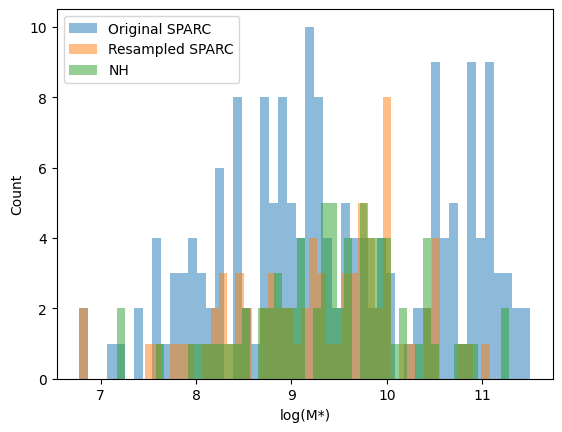

In [6]:
import matplotlib.pyplot as plt

plt.hist(sparc_logM_star, alpha=0.5, label='Original SPARC', bins = 50)
plt.hist(sparc_logM_star_resampled, alpha=0.5, label='Resampled SPARC', bins = 50)
plt.hist(m2, alpha=0.5, label='NH', bins = 50)
plt.xlabel('log(M*)')
plt.ylabel('Count')
plt.legend()
plt.show